In [ ]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, 
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [Blood](https://www.openml.org/search?type=data&status=active&id=1464)

In [2]:
dataset_id = 1464
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

[I 2025-04-10 16:11:41,504] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-10 16:11:41,511] Trial 0 finished with value: 0.6920077972709551 and parameters: {'penalty': 'l1', 'C': 0.1}. Best is trial 0 with value: 0.6920077972709551.
[I 2025-04-10 16:11:41,516] Trial 1 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 1e-05}. Best is trial 0 with value: 0.6920077972709551.
[I 2025-04-10 16:11:41,522] Trial 2 finished with value: 0.6695906432748537 and parameters: {'penalty': 'l2', 'C': 0.01}. Best is trial 0 with value: 0.6920077972709551.
[I 2025-04-10 16:11:41,527] Trial 3 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 1e-05}. Best is trial 0 with value: 0.6920077972709551.
[I 2025-04-10 16:11:41,531] Trial 4 finished with value: 0.702729044834308 and parameters: {'penalty': 'l2', 'C': 100}. Best is trial 4 with value: 0.702729044834308.
[I 2025-04-10 16:11:41,537] Trial 5 finished with value: 0.5 and parameters: {'p

ROC-AUC = 0.7544
F1 = 0.2727
Accuracy = 0.7867
Precision = 0.7500
Recall = 0.1667


In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

[I 2025-04-10 16:11:41,626] A new study created in memory with name: catboost_optimization
[I 2025-04-10 16:11:42,301] Trial 0 finished with value: 0.4892787524366472 and parameters: {'depth': 8, 'learning_rate': 0.1, 'l2_leaf_reg': 0.001}. Best is trial 0 with value: 0.4892787524366472.
[I 2025-04-10 16:11:42,572] Trial 1 finished with value: 0.6510721247563354 and parameters: {'depth': 2, 'learning_rate': 0.01, 'l2_leaf_reg': 0.001}. Best is trial 1 with value: 0.6510721247563354.
[I 2025-04-10 16:11:42,878] Trial 2 finished with value: 0.5906432748538012 and parameters: {'depth': 2, 'learning_rate': 0.3, 'l2_leaf_reg': 10.0}. Best is trial 1 with value: 0.6510721247563354.
[I 2025-04-10 16:11:44,344] Trial 3 finished with value: 0.5321637426900584 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 6.0}. Best is trial 1 with value: 0.6510721247563354.
[I 2025-04-10 16:11:44,712] Trial 4 finished with value: 0.4736842105263158 and parameters: {'depth': 4, 'learning_rat

ROC-AUC = 0.7027
F1 = 0.4286
Accuracy = 0.7867
Precision = 0.6000
Recall = 0.3333


In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

[I 2025-04-10 16:11:51,757] A new study created in memory with name: lgdm_optimization
[I 2025-04-10 16:11:51,990] Trial 0 finished with value: 0.621832358674464 and parameters: {'num_leaves': 8, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'learning_rate': 0.03}. Best is trial 0 with value: 0.621832358674464.
[I 2025-04-10 16:11:52,175] Trial 1 finished with value: 0.6193957115009747 and parameters: {'num_leaves': 4, 'reg_alpha': 0.0001, 'reg_lambda': 0.0001, 'learning_rate': 0.03}. Best is trial 0 with value: 0.621832358674464.
[I 2025-04-10 16:11:52,511] Trial 2 finished with value: 0.5916179337231968 and parameters: {'num_leaves': 8, 'reg_alpha': 1e-08, 'reg_lambda': 1e-06, 'learning_rate': 0.03}. Best is trial 0 with value: 0.621832358674464.
[I 2025-04-10 16:11:52,598] Trial 3 finished with value: 0.611111111111111 and parameters: {'num_leaves': 1024, 'reg_alpha': 1.0, 'reg_lambda': 1e-07, 'learning_rate': 0.3}. Best is trial 0 with value: 0.621832358674464.
[I 2025-04-10 16:11:52,879] T

ROC-AUC = 0.7286
F1 = 0.1667
Accuracy = 0.7333
Precision = 0.3333
Recall = 0.1111


In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


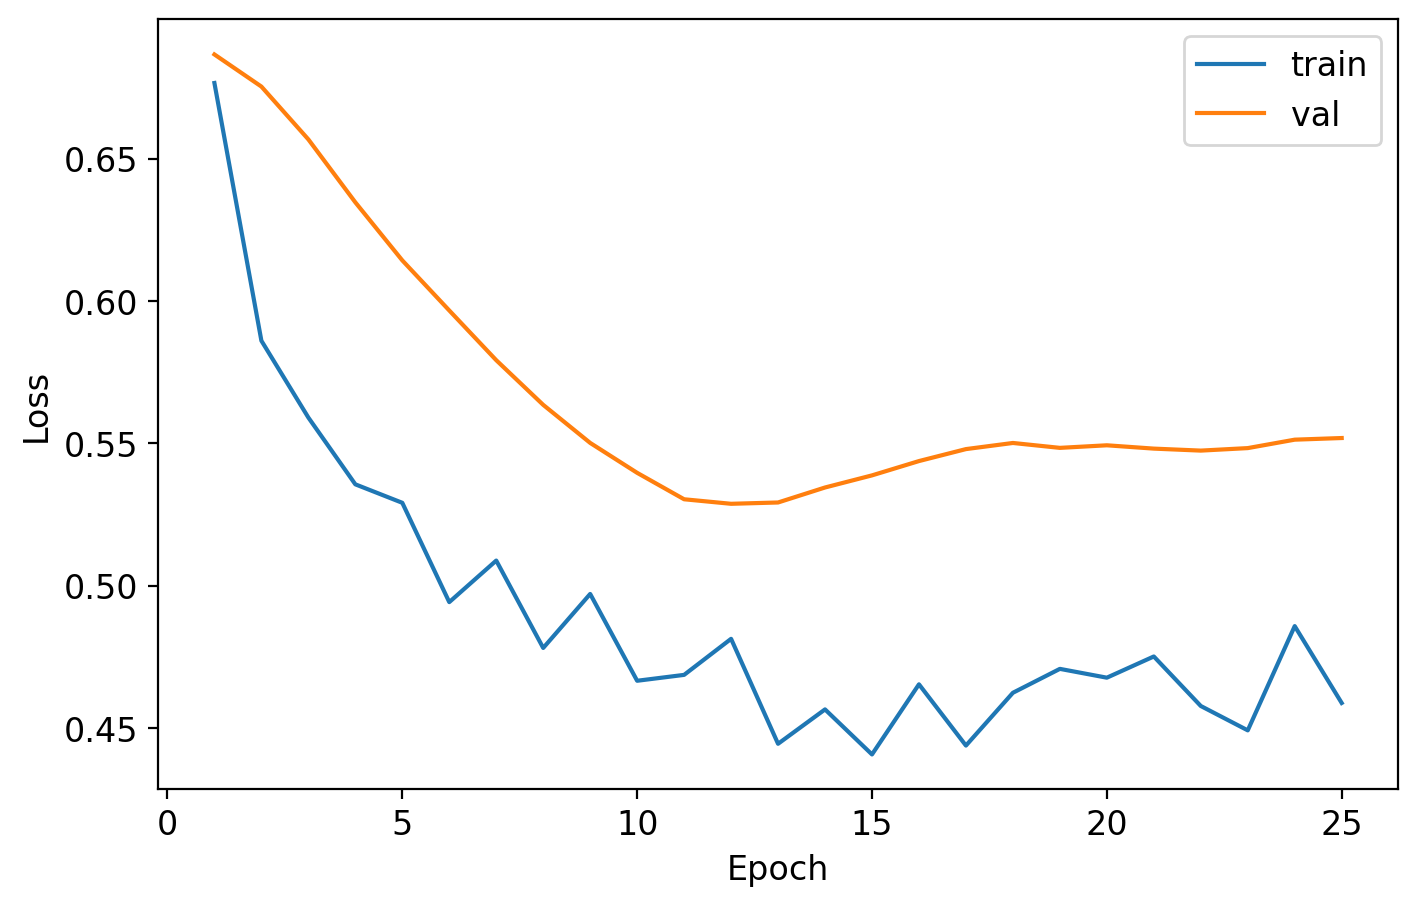

Epoch 25: train loss = 0.4589; valid loss = 0.5519


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.AdamW(net.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 25, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))

ROC-AUC = 0.7349
F1 = 0.4828
Accuracy = 0.8000
Precision = 0.6364
Recall = 0.3889
